In [125]:
from pathlib import Path
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv
DATASET_NAME = "hcp_schaefer_100_dataset" # suarez_MaMI_dataset"
PROJECT_NAME ="01_first_bigger_run_animal_0" # 76_90000_samples_animal_206" # 60_generally_finer_search_animal_0" # 26_testing_4_KS_folders_why_so_fast" # #  "2423_24rough_combined" # 24_testing_4_KS_folders_rougher_grid" # 20_sweep_with_individual_connectomes_eta_-7_and_gamma_-0.2"
base_output_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output")
project_path = base_output_path / "gnm" / DATASET_NAME / PROJECT_NAME

In [126]:
# from notebook_setup import setup
from vizman import viz
import numpy as np
from pathlib import Path

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

# from kaysons_visual_config import * # Kayson's file. 
from pypalettes import load_cmap
cmap = load_cmap("Aurora")

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome


In [127]:
file_emp_connectome_estimated_eta_and_gamma = project_path / "min_energy_results.csv"
# file_emp_connectome_calculated_graph_metrics = base_output_path + "/emprirical_analysis/empirical_analysis.csv"
# file_emp_connectome_calculated_graph_metrics = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm_old/suarez_MaMI_dataset/emprirical_analysis/empirical_analysis_weighted.csv"
# file_generated_connectome_calculated_graph_metrics = project_path / f"summary_all_metrics_for_exp_{PROJECT_NAME}.csv" # summary_all_metrics_for_exp_18_sweep_with_individual_connectomes_larger_eta_span.csv"

import pandas as pd
import seaborn as sns
df_best_eta_gamma = pd.read_csv(file_emp_connectome_estimated_eta_and_gamma)

In [128]:
df_best_eta_gamma

,subj_index,gamma,eta,energy
0,0,0.144444,-2.777778,0.20
1,1,0.144444,-3.777778,0.14
2,2,0.144444,-3.777778,0.19
3,3,0.144444,-3.777778,0.19
4,4,0.188889,-2.777778,0.21
5,5,0.188889,-2.777778,0.20
6,6,0.222222,-3.333333,0.20
7,7,0.144444,-2.777778,0.22
8,8,0.144444,-3.777778,0.17
9,9,0.177778,-3.000000,0.17


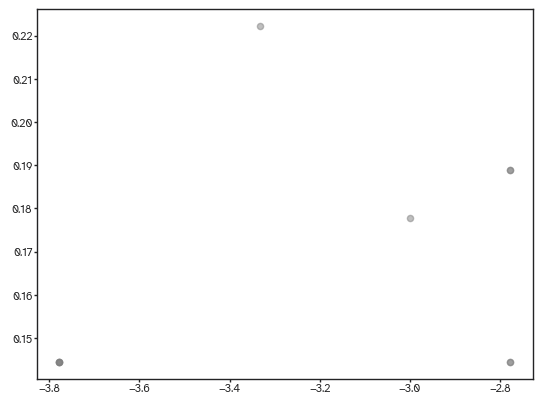

In [129]:
import matplotlib.pyplot as plt 

plt.scatter(
    df_best_eta_gamma["eta"],
    df_best_eta_gamma["gamma"],
    c="gray",
    alpha=0.5,
    s=20,
    label="All subjects",
)   

In [130]:
df_metrics_of_subj_0 = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/75_10000_samples_hopefully_no_lost_entries_gamma_-0p1_to_1_animal_0/all_metrics_for_75_10000_samples_hopefully_no_lost_entries_gamma_-0p1_to_1_animal_0.csv")
df_metrics_of_subj_0 = df_metrics_of_subj_0[["eta", "gamma", "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]]

Text(0.5, 1.0, "Estimated best fitting GNM parameters for HCP subjects in animal 0's distance matrix landscape")

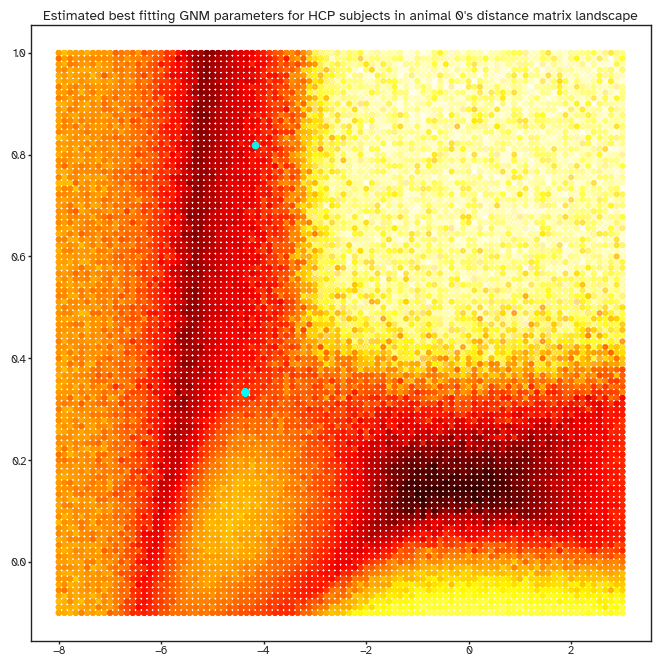

In [97]:
plt.figure(figsize=(8,8))

plt.scatter(df_metrics_of_subj_0["eta"], df_metrics_of_subj_0["gamma"], c=df_metrics_of_subj_0["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], alpha=0.5, s=10, cmap="hot")

plt.scatter(
    df_best_eta_gamma["eta"],
    df_best_eta_gamma["gamma"],
    c="cyan",
    alpha=0.5,
    s=20,
    label="All subjects",
)   

plt.title("Estimated best fitting GNM parameters for HCP subjects in animal 0's distance matrix landscape")

# Individual connectome fits

In [101]:
df_indiv_76 = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv") 
df_all_metrics_76 = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/76_90000_samples_animal_206/all_metrics_for_76_90000_samples_animal_206.csv")

In [13]:
df_indiv.head()

,network_index,filename,eta,gamma,id,MaxCrit_indiv_0,MaxCrit_indiv_1,MaxCrit_indiv_2,MaxCrit_indiv_3,MaxCrit_indiv_4,...,MaxCrit_indiv_90,MaxCrit_indiv_91,MaxCrit_indiv_92,MaxCrit_indiv_93,MaxCrit_indiv_94,MaxCrit_indiv_95,MaxCrit_indiv_96,MaxCrit_indiv_97,MaxCrit_indiv_98,MaxCrit_indiv_99
0,0,net_eta-1.488294363021851_gamma0.0287625398486...,-1.488294,0.028763,0,0.900000,0.890000,0.920000,0.900000,0.930000,...,0.890000,0.900000,0.910000,0.920000,0.910000,0.900000,0.910000,0.910000,0.880000,0.920000
1,1,net_eta2.558528423309326_gamma0.46287626028060...,2.558528,0.462876,0,0.860000,0.880000,0.920000,0.930000,0.850000,...,0.890000,0.900000,0.890000,0.900000,0.900000,0.850000,0.900000,0.880000,0.880000,0.880000
2,2,net_eta2.264214038848877_gamma0.44448161125183...,2.264214,0.444482,0,0.760000,0.770000,0.770000,0.870000,0.760000,...,0.790000,0.770000,0.780000,0.770000,0.760000,0.770000,0.820000,0.760000,0.770000,0.780000
3,3,net_eta2.337792634963989_gamma0.79397994279861...,2.337793,0.793980,0,0.930000,0.920000,0.930000,0.950000,0.920000,...,0.940000,0.930000,0.940000,0.930000,0.940000,0.900000,0.940000,0.900000,0.930000,0.930000
4,4,net_eta2.337792634963989_gamma0.28260868787765...,2.337793,0.282609,0,0.567677,0.575758,0.606061,0.626263,0.593939,...,0.565657,0.579798,0.620202,0.616162,0.585859,0.624242,0.606061,0.591919,0.565657,0.614141


In [61]:
# remove row with id == 496
df_indiv = df_indiv[df_indiv.index != 496]

In [69]:
best_fit_index_arr = [] 
for i in range(100): 
    # get the id of df_indiv[f"MaxCrit_indiv_{i}"].min()
   best_fit_index = df_indiv[df_indiv[f"MaxCrit_indiv_{i}"] == df_indiv[f"MaxCrit_indiv_{i}"].min()].index[0]
   print(best_fit_index)
   best_fit_index_arr.append(best_fit_index)
#    print(df_indiv.iloc[best_fit_index])

7189
2090
2090
7189
2090
7189
2090
2090
7189
7189
2090
7189
7189
2090
2090
4243
2090
2090
7189
2090
7189
2090
7189
2090
1929
2090
2090
8812
7189
2090
2090
2090
2090
1929
7189
4243
7189
2090
2090
7189
2090
1929
7189
2090
2090
2090
2090
2090
4243
7189
2090
2090
2090
1929
4243
7189
2090
1929
7189
7189
7189
7189
2090
2090
7189
7189
2090
7189
2090
7189
7189
501
1929
1929
2090
1929
2090
2090
1929
2090
2090
2090
2090
2090
2090
2090
4243
7189
1929
7189
7189
7189
7189
2090
2090
7189
7189
7189
7189
2090


(array([ 1.,  0.,  0.,  0.,  0., 58.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 35.,  0.,
         0.,  0.,  0.,  1.]),
 array([ 501.        ,  778.03333333, 1055.06666667, 1332.1       ,
        1609.13333333, 1886.16666667, 2163.2       , 2440.23333333,
        2717.26666667, 2994.3       , 3271.33333333, 3548.36666667,
        3825.4       , 4102.43333333, 4379.46666667, 4656.5       ,
        4933.53333333, 5210.56666667, 5487.6       , 5764.63333333,
        6041.66666667, 6318.7       , 6595.73333333, 6872.76666667,
        7149.8       , 7426.83333333, 7703.86666667, 7980.9       ,
        8257.93333333, 8534.96666667, 8812.        ]),
 <BarContainer object of 30 artists>)

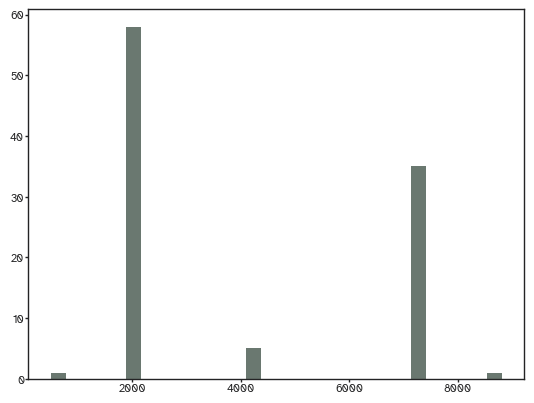

In [70]:
plt.hist(best_fit_index_arr, bins=30)

In [71]:
set(best_fit_index_arr)

{np.int64(501),
 np.int64(1929),
 np.int64(2090),
 np.int64(4243),
 np.int64(7189),
 np.int64(8812)}

In [73]:
# Get df with the indexes of best_fit_index_arr
df_indiv_best = df_indiv[df_indiv.index.isin(best_fit_index_arr)]
df_indiv_best

,network_index,filename,eta,gamma,id,MaxCrit_indiv_0,MaxCrit_indiv_1,MaxCrit_indiv_2,MaxCrit_indiv_3,MaxCrit_indiv_4,...,MaxCrit_indiv_90,MaxCrit_indiv_91,MaxCrit_indiv_92,MaxCrit_indiv_93,MaxCrit_indiv_94,MaxCrit_indiv_95,MaxCrit_indiv_96,MaxCrit_indiv_97,MaxCrit_indiv_98,MaxCrit_indiv_99
501,373,net_eta-3.107023239135742_gamma0.4040133655071...,-3.107023,0.404013,0,0.436364,0.470000,0.500000,0.580000,0.480000,...,0.460000,0.500000,0.500000,0.472727,0.458586,0.494950,0.500000,0.468687,0.450000,0.520000
1929,1801,net_eta-4.17391300201416_gamma0.81973242759704...,-4.173913,0.819732,0,0.440404,0.446465,0.466667,0.488889,0.450505,...,0.434343,0.430303,0.488889,0.470707,0.460606,0.496970,0.470707,0.472727,0.438384,0.488889
2090,1962,net_eta-4.431437969207764_gamma0.4702341258525...,-4.431438,0.470234,0,0.434343,0.444444,0.462626,0.482828,0.448485,...,0.432323,0.428283,0.484848,0.468687,0.454545,0.492929,0.464646,0.466667,0.432323,0.486869
4243,4115,net_eta-3.033444881439209_gamma0.2494983226060...,-3.033445,0.249498,0,0.442424,0.448485,0.468687,0.490909,0.454545,...,0.442424,0.430303,0.496970,0.474747,0.466667,0.498990,0.474747,0.470707,0.444444,0.486869
7189,7061,net_eta-3.438127040863037_gamma0.2678929865360...,-3.438127,0.267893,0,0.434343,0.446465,0.462626,0.482828,0.448485,...,0.430303,0.426263,0.482828,0.472727,0.454545,0.490909,0.460606,0.464646,0.432323,0.486869
8812,8684,net_eta-1.7826087474823_gamma0.21270902454853_...,-1.782609,0.212709,0,0.440404,0.448485,0.466667,0.486869,0.452525,...,0.440404,0.432323,0.492929,0.474747,0.462626,0.496970,0.470707,0.468687,0.442424,0.490909


0.4323232471942901


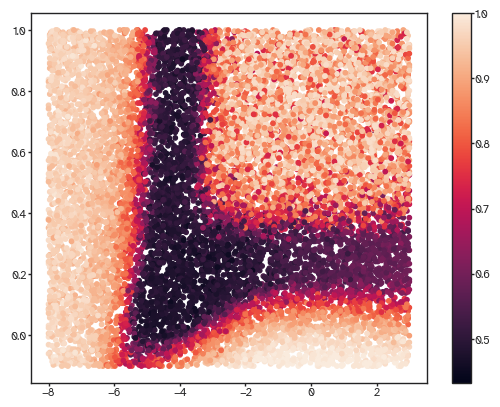

In [99]:
# plt.scatter(df_indiv["MaxCrit_indiv_0"], df_indiv["MaxCrit_indiv_1"], c=df_indiv["eta"], alpha=1, s=30) 
plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_1"], alpha=1, s=10) 
plt.colorbar()
print(df_indiv["MaxCrit_indiv_1"].min())

0.4323232471942901


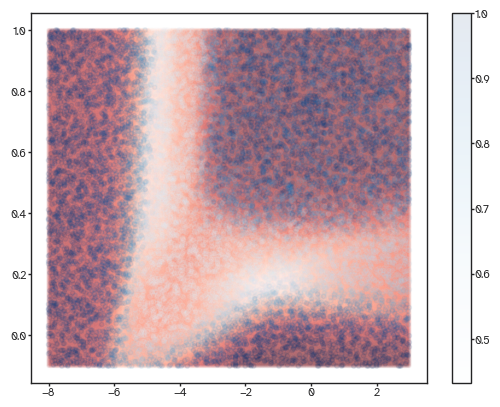

In [112]:
# plt.scatter(df_indiv["MaxCrit_indiv_0"], df_indiv["MaxCrit_indiv_1"], c=df_indiv["eta"], alpha=1, s=30) 
plt.scatter(df_all_metrics_76["eta"], df_all_metrics_76["gamma"], c=df_all_metrics_76["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], cmap="Reds", alpha=0.05, s=5)
plt.scatter(df_indiv_76["eta"], df_indiv_76["gamma"], c=df_indiv_76["MaxCrit_indiv_1"], cmap="Blues", alpha=0.1, s=10) 

plt.colorbar()
print(df_indiv_76["MaxCrit_indiv_1"].min())

In [121]:
df_indiv = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/00_default_animal_0/all_metrics_for_00_default_animal_0.csv") 

# plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], alpha=0.5, s=10)
# df_indiv_best_0 = df_indiv[df_indiv["MaxCrit_indiv_0"] == df_indiv["MaxCrit_indiv_0"].min()]
df_indiv_best_1 = df_indiv[df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"] == df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"].min()][["eta", "gamma", "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]]
# plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7615658824455241..1.0].


Blue channel min: 0.4323232471942901
Red channel min: 0.0799999982118606


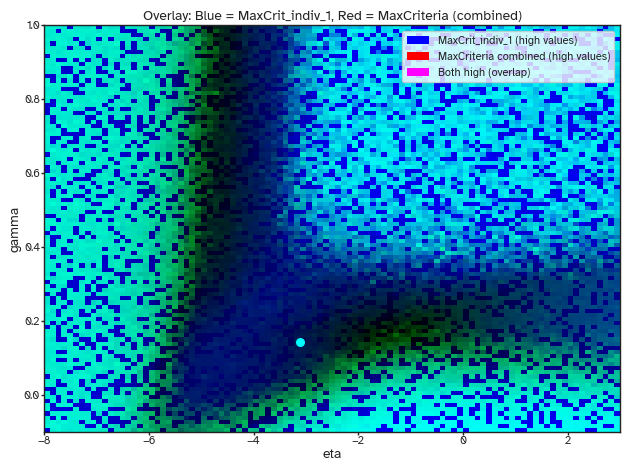

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# Define the binning parameters
n_bins = 99

# Get the ranges for binning (use combined min/max to ensure same grid)
eta_min = min(df_indiv_76["eta"].min(), df_all_metrics_76["eta"].min())
eta_max = max(df_indiv_76["eta"].max(), df_all_metrics_76["eta"].max())
gamma_min = min(df_indiv_76["gamma"].min(), df_all_metrics_76["gamma"].min())
gamma_max = max(df_indiv_76["gamma"].max(), df_all_metrics_76["gamma"].max())

# Create bins
eta_bins = np.linspace(eta_min, eta_max, n_bins + 1)
gamma_bins = np.linspace(gamma_min, gamma_max, n_bins + 1)

# Bin the data and compute mean values in each bin
# For blue channel (df_indiv_76)
blue_data, eta_edges, gamma_edges = np.histogram2d(
    df_indiv_76["eta"], 
    df_indiv_76["gamma"], 
    bins=[eta_bins, gamma_bins],
    weights=df_indiv_76["MaxCrit_indiv_1"]
)
blue_counts, _, _ = np.histogram2d(
    df_indiv_76["eta"], 
    df_indiv_76["gamma"], 
    bins=[eta_bins, gamma_bins]
)
blue_mean = np.divide(blue_data, blue_counts, where=blue_counts>0, out=np.zeros_like(blue_data))

# For red channel (df_all_metrics_76)
red_data, _, _ = np.histogram2d(
    df_all_metrics_76["eta"], 
    df_all_metrics_76["gamma"], 
    bins=[eta_bins, gamma_bins],
    weights=df_all_metrics_76["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]
)
red_counts, _, _ = np.histogram2d(
    df_all_metrics_76["eta"], 
    df_all_metrics_76["gamma"], 
    bins=[eta_bins, gamma_bins]
)
red_mean = np.divide(red_data, red_counts, where=red_counts>0, out=np.zeros_like(red_data))

# Normalize to [0, 1] range
blue_norm = (blue_mean - np.nanmin(blue_mean[blue_counts > 0])) / (np.nanmax(blue_mean[blue_counts > 0]) - np.nanmin(blue_mean[blue_counts > 0]))
red_norm = (red_mean - np.nanmin(red_mean[red_counts > 0])) / (np.nanmax(red_mean[red_counts > 0]) - np.nanmin(red_mean[red_counts > 0]))

# Replace NaNs with 0
blue_norm = np.nan_to_num(blue_norm)
red_norm = np.nan_to_num(red_norm)

# Create RGB image (transpose to match imshow's orientation)
rgb_image = np.zeros((n_bins, n_bins, 3))
rgb_image[:, :, 2] = red_norm.T  # Red channel
rgb_image[:, :, 1] = blue_norm.T  # green (1) or Blue (2) channel

# Plot
# plt.figure(figsize=(10, 8))
plt.imshow(rgb_image, origin='lower', extent=[eta_min, eta_max, gamma_min, gamma_max], aspect='auto')
plt.xlabel('eta')
plt.ylabel('gamma')
plt.title('Overlay: Blue = MaxCrit_indiv_1, Red = MaxCriteria (combined)')

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='MaxCrit_indiv_1 (high values)'),
    Patch(facecolor='red', label='MaxCriteria combined (high values)'),
    Patch(facecolor='magenta', label='Both high (overlap)')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()


print(f"Blue channel min: {df_indiv_76['MaxCrit_indiv_1'].min()}")
print(f"Red channel min: {df_all_metrics_76['MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)'].min()}")

plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

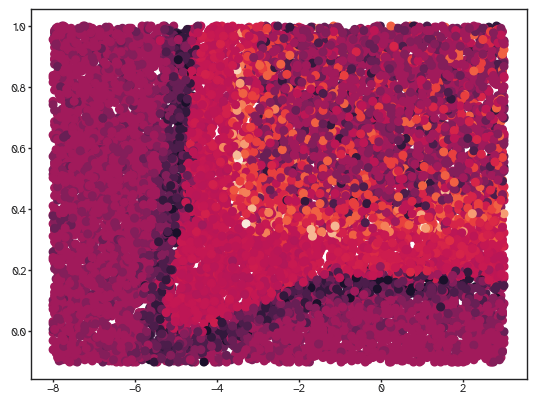

In [ ]:
# plt.scatter(df_indiv["MaxCrit_indiv_0"], df_indiv["MaxCrit_indiv_1"], c=df_indiv["eta"], alpha=1, s=30) 
# plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_1"]-df_indiv["MaxCrit_indiv_0"], alpha=1, s=30) 
plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_1"]-df_indiv["MaxCrit_indiv_0"], alpha=1, s=30) 

In [50]:
best_fits_df = {} #  pd.DataFrame()
for i in range(10): 
    df_indiv_best_0 = df_indiv[df_indiv[f"MaxCrit_indiv_{i}"] == df_indiv[f"MaxCrit_indiv_{i}"].min()][["eta", "gamma", f"MaxCrit_indiv_{i}"]]
    best_fits_df[i] = df_indiv_best_0

best_fits_df = pd.concat(best_fits_df.values(), ignore_index=True)
best_fits_df.head()

,eta,gamma,MaxCrit_indiv_0,MaxCrit_indiv_1,MaxCrit_indiv_2,MaxCrit_indiv_3,MaxCrit_indiv_4,MaxCrit_indiv_5,MaxCrit_indiv_6,MaxCrit_indiv_7,MaxCrit_indiv_8,MaxCrit_indiv_9
0,-4.35786,0.334114,0.420202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-4.35786,0.334114,NaN,0.432323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-4.35786,0.334114,NaN,NaN,0.450505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-4.35786,0.334114,NaN,NaN,NaN,0.468687,NaN,NaN,NaN,NaN,NaN,NaN
4,-4.35786,0.334114,NaN,NaN,NaN,NaN,0.438384,NaN,NaN,NaN,NaN,NaN


In [ ]:
best_fits

In [75]:

plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_0"], alpha=0.5, s=10)
# df_indiv_best_0 = df_indiv[df_indiv["MaxCrit_indiv_0"] == df_indiv["MaxCrit_indiv_0"].min()]
df_indiv_best_1 = df_indiv[df_indiv["MaxCrit_indiv_1"] == df_indiv["MaxCrit_indiv_1"].min()][["eta", "gamma", "MaxCrit_indiv_1"]]
plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

KeyError: 'MaxCrit_indiv_0'

In [ ]:
# get the row and index of df_indiv["MaxCrit_indiv_1"] == df_indiv["MaxCrit_indiv_1"].min()
df_indiv_best_1 = df_indiv[df_indiv["MaxCrit_indiv_1"] == df_indiv["MaxCrit_indiv_1"].min()][["eta", "gamma", "MaxCrit_indiv_1"]]

# best_fit_index_1 = df_indiv_best_1.index[1]
# best_fit_row_1 = df_indiv_best_1.iloc[1]
best_fit_row_1 = df_indiv_best_1 # .iloc[1]
best_fit_row_1

,eta,gamma,MaxCrit_indiv_1
496,-4.35786,0.334114,0.432323


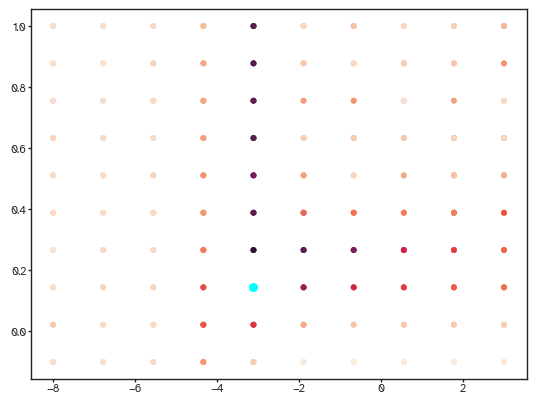

In [78]:
df_indiv = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/00_default_animal_0/all_metrics_for_00_default_animal_0.csv") 

plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], alpha=0.5, s=10)
# df_indiv_best_0 = df_indiv[df_indiv["MaxCrit_indiv_0"] == df_indiv["MaxCrit_indiv_0"].min()]
df_indiv_best_1 = df_indiv[df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"] == df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"].min()][["eta", "gamma", "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]]
plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

In [77]:
plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_1"], alpha=0.5, s=10, cmap="hot")
df_indiv_best_1 = df_indiv[df_indiv["MaxCrit_indiv_1"] == df_indiv["MaxCrit_indiv_1"].min()]
df_indiv_best_1.head()
plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

plt.title("One human connectome fit to GNMs generated with animal 0's distance matrix")

KeyError: 'MaxCrit_indiv_1'

In [45]:
best_fit_row_1["MaxCrit_indiv_0"].values

array([0.42020205])

In [ ]:
df_indiv_best_1["diff_between_0_and_1"] = df_indiv_best_1["MaxCrit_indiv_1"].values - best_fit_row_1["MaxCrit_indiv_0"].values 

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_3675/2550699675.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_indiv_best_1["diff_between_0_and_1"] = df_indiv_best_1["MaxCrit_indiv_1"].values - best_fit_row_1["MaxCrit_indiv_0"].values # + np.abs(df_indiv_best_1["gamma"] - best_fit_row_1["gamma"].values[0])


In [11]:
df_indiv["MaxCrit_indiv_0"]

0        0.900000
1        0.860000
2        0.760000
3        0.930000
4        0.567677
           ...   
12222    0.503030
12223    0.980000
12224    0.950000
12225    0.770000
12226    0.484848
Name: MaxCrit_indiv_0, Length: 12227, dtype: float64

In [12]:
df_indiv["MaxCrit_indiv_0"].min(), 

(np.float64(0.4202020466327667),)